# SILVA Physics-Informed Equilibrium

This lab derives a physics-informed equilibrium for an ODE initial-value
problem, computes time derivatives with the implicit function theorem, and
trains a tiny linear-decay task with boundary, equation, and Jacobian terms.
The construction follows Physics-Informed Deep Equilibrium Models [51].

<!-- silva-numbered-citations:start -->
**Numbered literature:** [1](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [4](https://jseluis.github.io/silva-networks/paper/references/#ref-4), [6](https://jseluis.github.io/silva-networks/paper/references/#ref-6), [14](https://jseluis.github.io/silva-networks/paper/references/#ref-14), [51](https://jseluis.github.io/silva-networks/paper/references/#ref-51). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [Path.cwd(), Path("/content/silva-networks")]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})

from silva_networks import (
    SILVAPhysicsInformedEquilibrium,
    SolverConfig,
    make_linear_ivp_dataset,
)

torch.manual_seed(240)

## 1. Initial-Value Problem

Consider

$$
\frac{dy}{dt}=N(t,y(t)),
\qquad y(t_0)=y_0.
$$

A physics-informed model is trained at collocation times without requiring a
target state at every point. The package's analytic batch supplies targets only
so this notebook can measure error after training.

In [3]:
data = make_linear_ivp_dataset(points=9, final_time=1.5, rate=-0.5)
assert data.equation_residual().abs().max() == 0
assert torch.allclose(data.target[:1], data.initial_state)
print("collocation points:", data.times.shape[0])
print("exact final state:", float(data.target[-1]))

collocation points: 9
exact final state: 0.2361832708120346


## 2. State Is Defined Implicitly

Instead of evaluating a finite stack, define

$$
z^\star(t)=f_\theta(z^\star(t),t),
\qquad \widehat y(t)=Q_\psi(z^\star(t)).
$$

In SILVA, time enters through the source branch and the latent state enters
through the self-interaction branch. A standard output loss can use the
package's implicit adjoint, avoiding storage of every forward solver iterate.

## 3. Time Derivative from the Implicit Function Theorem

Differentiate the fixed-point equation:

$$
\frac{dz^\star}{dt}
=J_zf_\theta\frac{dz^\star}{dt}+J_tf_\theta.
$$

Therefore

$$
\frac{dz^\star}{dt}
=(I-J_zf_\theta)^{-1}J_tf_\theta,
\qquad
\frac{d\widehat y}{dt}=J_Q\frac{dz^\star}{dt}.
$$

`implicit_time_derivative` solves this system exactly with dense Jacobians. It
is transparent and differentiable for small latent dimensions; large systems
should replace the dense solve with matrix-free products.

In [4]:
model = SILVAPhysicsInformedEquilibrium(
    state_dim=4,
    output_dim=1,
    state_scale=0.15,
    config=SolverConfig(
        solver="picard",
        max_iter=15,
        tol=1e-6,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
initial = model(data.times, return_result=True)
derivative = model.implicit_time_derivative(data.times, initial.state)
assert derivative.shape == initial.output.shape == data.target.shape
print("equilibrium residual:", initial.solver_result.residual)

equilibrium residual: 5.5275074828387e-07


## 4. Three-Term Physics-Informed Objective

The decomposed objective is

$$
\mathcal J_b=\|\widehat y(t_0)-y_0\|_2^2,
$$

$$
\mathcal J_N
=\frac1M\sum_{i=1}^M
\left\|\frac{d\widehat y(t_i)}{dt}
-N(t_i,\widehat y(t_i))\right\|_2^2,
$$

$$
\mathcal J
=\mathcal J_b+\lambda\mathcal J_N
+\kappa\|J_zf_\theta\|_F^2.
$$

The Jacobian term is estimated with Rademacher probes [6, 14, 51]. It is a
solver-conditioning term, not the differential-equation residual.

In [5]:
loss = model.physics_loss(
    data.times,
    data.dynamics,
    initial_time=data.times[:1],
    initial_state=data.initial_state,
    physics_weight=1.0,
    jacobian_weight=1e-3,
    jacobian_samples=1,
)
print("boundary:", float(loss.initial))
print("ODE residual:", float(loss.residual))
print("Jacobian estimate:", float(loss.jacobian))

boundary: 0.4718993604183197
ODE residual: 0.23153440654277802
Jacobian estimate: 0.08972296863794327


## 5. Tiny Physics-Only Training Run

No trajectory targets appear in the optimization objective below. They are
used afterward only to calculate an error curve. This separation is essential
when describing a physics-informed experiment.

In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
history = []
for _ in range(8):
    optimizer.zero_grad()
    terms = model.physics_loss(
        data.times,
        data.dynamics,
        initial_time=data.times[:1],
        initial_state=data.initial_state,
        jacobian_weight=1e-3,
    )
    terms.total.backward()
    optimizer.step()
    history.append((float(terms.initial.detach()), float(terms.residual.detach())))

trained = model(data.times, return_result=True)
trajectory_mse = torch.nn.functional.mse_loss(trained.output, data.target)
print("trajectory MSE used for evaluation:", float(trajectory_mse))

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


trajectory MSE used for evaluation: 0.0450901985168457


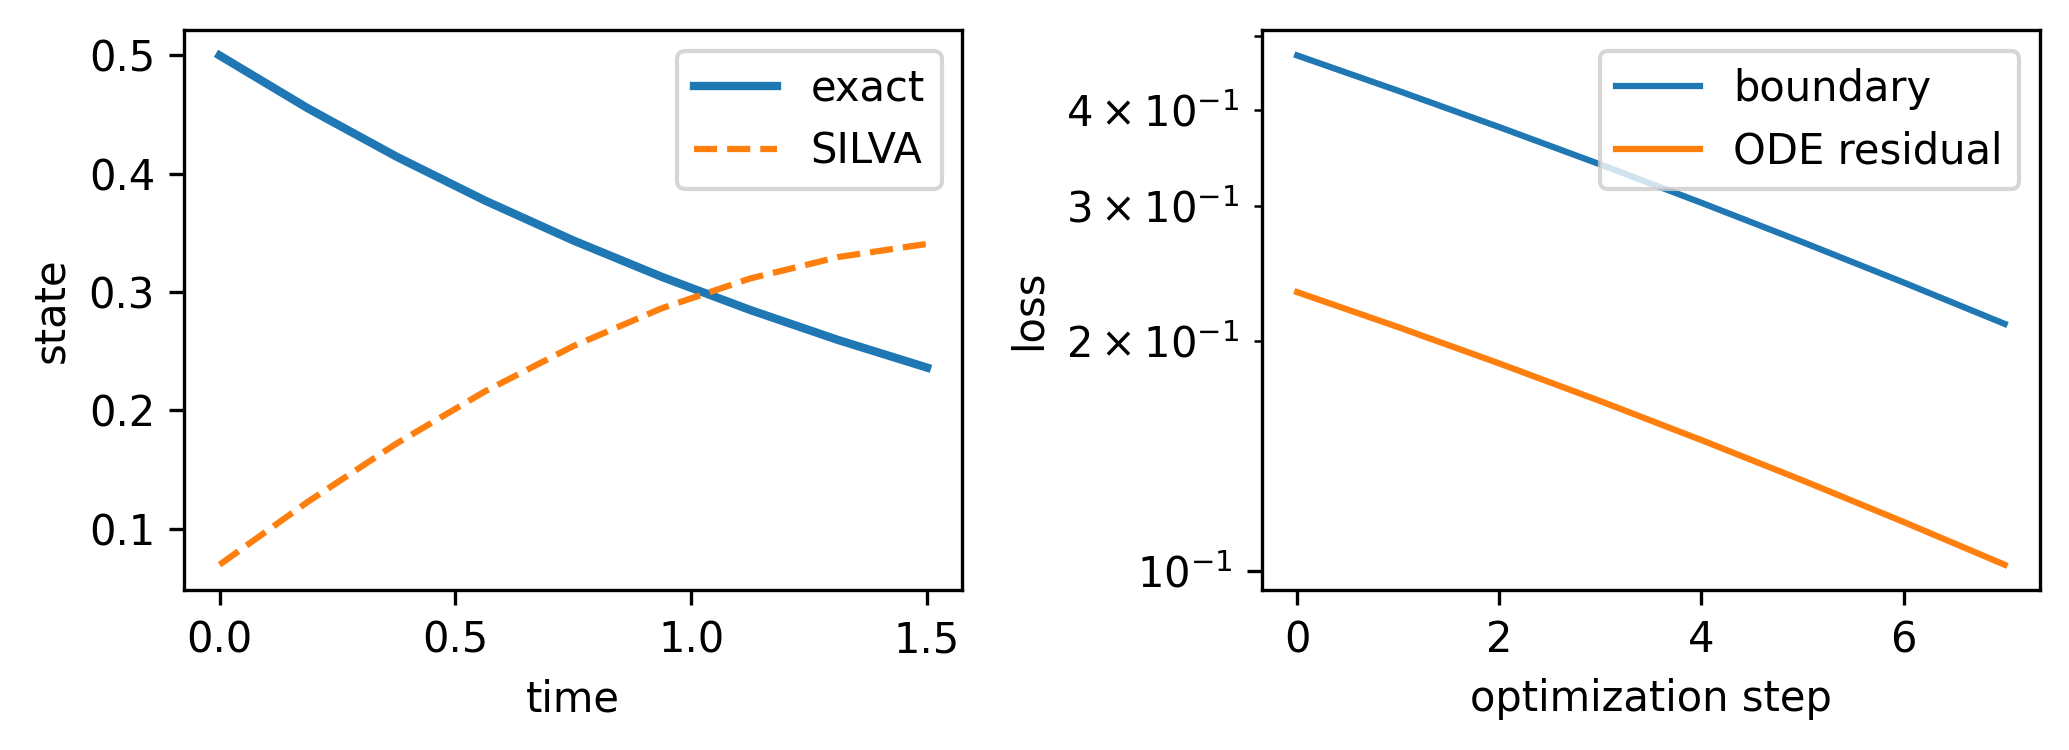

In [7]:
figure, axes = plt.subplots(1, 2, figsize=(7.0, 2.6))
axes[0].plot(data.times[:, 0], data.target[:, 0], label="exact", linewidth=2)
axes[0].plot(data.times[:, 0], trained.output.detach()[:, 0], "--", label="SILVA")
axes[0].set(xlabel="time", ylabel="state")
axes[0].legend()
axes[1].semilogy([item[0] for item in history], label="boundary")
axes[1].semilogy([item[1] for item in history], label="ODE residual")
axes[1].set(xlabel="optimization step", ylabel="loss")
axes[1].legend()
figure.tight_layout()
plt.show()

## 6. Stiff Systems and Scaling

An equilibrium layer does not automatically solve stiffness. Stability depends
on the transition, root solver, Jacobian spectrum, collocation distribution,
and loss balancing. For larger states, use matrix-free implicit products,
report forward and backward tolerances separately, and compare against a
trusted numerical integrator on the same time interval.

## Where to Go Next

| Question | Page |
| --- | --- |
| How is the implicit time derivative obtained? | [Physics-Informed Equilibria](https://jseluis.github.io/silva-networks/learn/physics-informed-equilibria/#implicit-time-derivative) |
| Which analytic ODE is used? | [Advanced Equilibrium Datasets](https://jseluis.github.io/silva-networks/learn/advanced-equilibrium-datasets/#linear-ode-ivp) |
| Which physics-loss objects are public? | [Physics-Informed API](https://jseluis.github.io/silva-networks/api/physics_informed/) |
